# Transaction Time Series Data Analysis
In this notebook, the transactions data (amount of sales done in each store per day) is analyzed to check if there are relevant annual time series patterns (seasonality, trend, stationarity and noise).

It uses a line plot to check seasonality and trend patterns on the data, as well seasonal decomposition and a boxplot, that also allows to see the data's noise. The ADF test is used to check data's stationarity.

This analysis is made for the whole dataset and for each granularity.

# 1. Load data

## 1. 1. Load data and check general info

In [11]:
import pandas as pd
import numpy as np

df_transactions = pd.read_csv('../data/transactions.csv')

df_transactions['date'] = pd.to_datetime(df_transactions['date'])

# Remove august, 2017 since it's not a full month
# and may get the analysis biased
df_transactions = df_transactions[df_transactions['date'] <= '2017-07-30']

display(df_transactions)

,date,store_nbr,transactions
0,2013-01-01,25,770
1,2013-01-02,1,2111
2,2013-01-02,2,2358
3,2013-01-02,3,3487
4,2013-01-02,4,1922
...,...,...,...
82619,2017-07-30,50,3069
82620,2017-07-30,51,1859
82621,2017-07-30,52,2580
82622,2017-07-30,53,1422


In [12]:
# General data's info
print(df_transactions.info())
display(df_transactions.describe())

<class 'pandas.core.frame.DataFrame'>
Index: 82624 entries, 0 to 82623
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          82624 non-null  datetime64[ns]
 1   store_nbr     82624 non-null  int64         
 2   transactions  82624 non-null  int64         
dtypes: datetime64[ns](1), int64(2)
memory usage: 2.5 MB
None


,date,store_nbr,transactions
count,82624,82624.000000,82624.000000
mean,2015-05-12 04:53:12.873741056,26.933373,1695.084479
min,2013-01-01 00:00:00,1.000000,5.000000
25%,2014-03-22 00:00:00,13.000000,1046.000000
50%,2015-05-30 00:00:00,27.000000,1393.000000
75%,2016-07-02 00:00:00,40.000000,2080.000000
max,2017-07-30 00:00:00,54.000000,8359.000000
std,NaN,15.608331,963.877819


# 2. Analysis for the whole data

## 2. 1. Trend Analysis

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()

df_transactions['month_year'] = df_transactions['date'].dt.to_period('M').dt.start_time

df_transactions_monthly = (
     df_transactions.groupby('month_year')['transactions'].sum()
    .reset_index()
    .sort_values(by='month_year')
)

display(df_transactions_monthly.head(n=5))
display(df_transactions_monthly.tail(n=5))

,month_year,transactions
0,2013-01-01,2289558
1,2013-02-01,2169615
2,2013-03-01,2458683
3,2013-04-01,2344905
4,2013-05-01,2467465


,month_year,transactions
50,2017-03-01,2680645
51,2017-04-01,2667808
52,2017-05-01,2801884
53,2017-06-01,2668863
54,2017-07-01,2695433


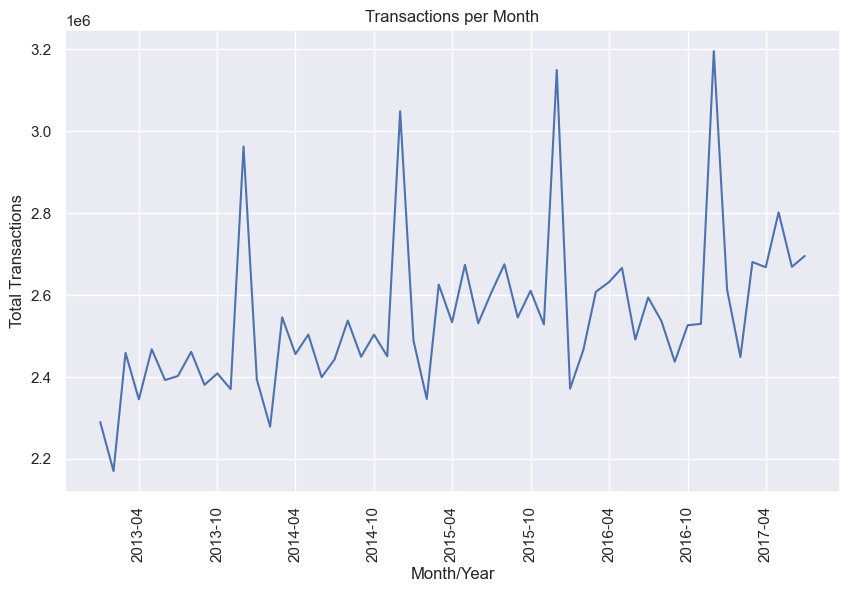

In [ ]:
import matplotlib.dates as mdates

plt.rcParams['figure.figsize'] = (10, 6)

# Creating lineplot to check trend visually
ax = sns.lineplot(
    data=df_transactions_monthly,
    x='month_year',
    y='transactions'
)

ax.set_xlabel('Month/Year')
ax.set_ylabel('Total Transactions')
ax.set_title('Transactions per Month')

# ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
# ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.xticks(rotation=90)

plt.show()

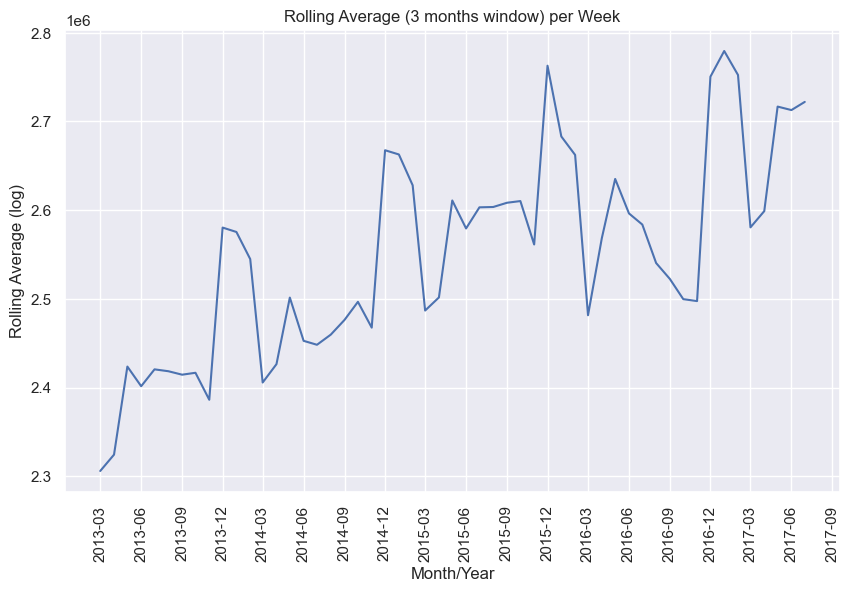

In [21]:
# Calculating rolling mean to check trend numerically
df_transactions_monthly["rolling_avg"] = df_transactions_monthly["transactions"].rolling(window=3).mean()

ax = sns.lineplot(
    data=df_transactions_monthly,
    x='month_year',
    y='rolling_avg'
)

ax.set_xlabel('Month/Year')
ax.set_ylabel('Rolling Average (log)')

ax.set_title('Rolling Average (3 months window) per Week')

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.xticks(rotation=90)

plt.show()

We can see a growing trend in the data.

## 2. 2. Seasonality

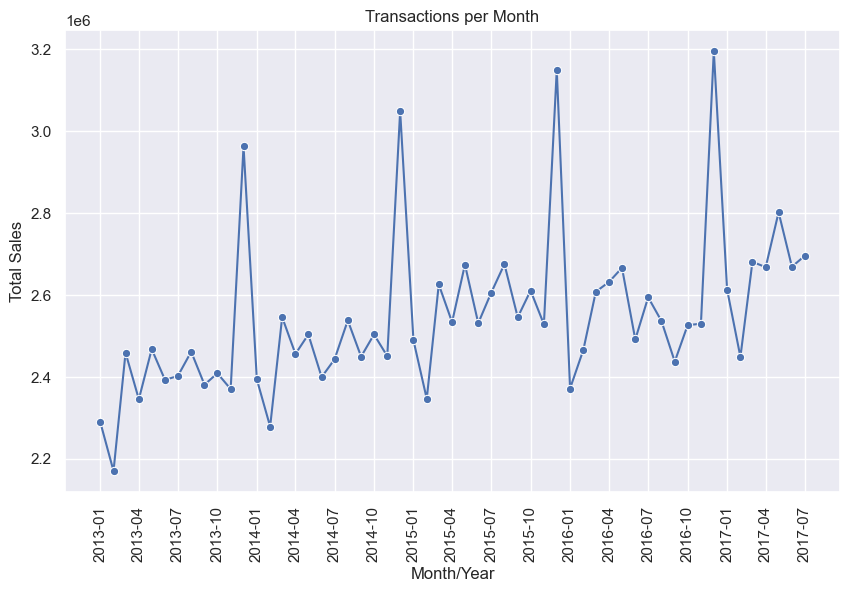

In [29]:
ax = sns.lineplot(
    data=df_transactions_monthly,
    x='month_year',
    y='transactions',
    marker='o'
)

ax.set_xlabel('Month/Year')
ax.set_ylabel('Total Sales')
ax.set_title('Transactions per Month')

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.xticks(rotation=90)

plt.show()

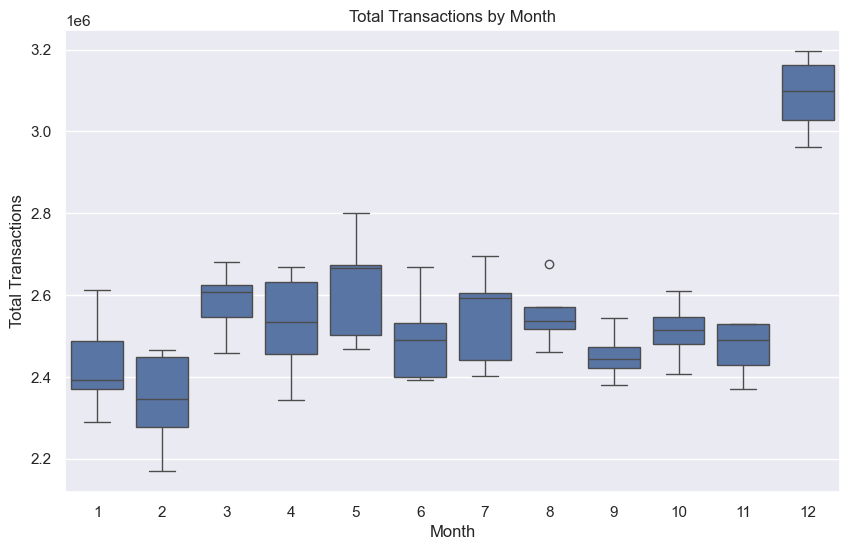

,month,transactions
4,5,13112679
2,3,12917913
6,7,12738613
3,4,12633531
5,6,12482179
11,12,12357808
0,1,12156198
1,2,11707934
7,8,10209879
9,10,10048234


In [24]:
# Boxplot by month
df_transactions_monthly['month'] = df_transactions_monthly['month_year'].dt.month

ax = sns.boxplot(
    data=df_transactions_monthly,
    x='month',
    y='transactions'
)

ax.set_title('Total Transactions by Month')
ax.set_xlabel('Month')
ax.set_ylabel('Total Transactions')

plt.show()

display(df_transactions_monthly.groupby('month')['transactions'].sum().reset_index().sort_values(by='transactions', ascending=False))

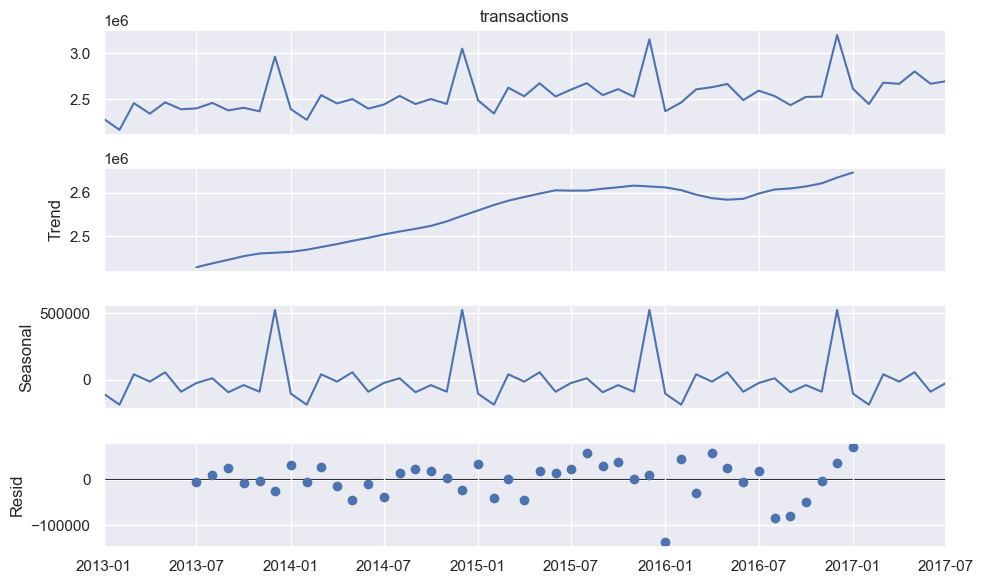

In [27]:
# Using seasonal decompose
from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(
    df_transactions_monthly.set_index("month_year")["transactions"],
    model="additive",
    period=12
)

result.plot()
plt.show()

In [28]:
# Variance by component
import numpy as np

trend_var = np.var(result.trend.dropna())
season_var = np.var(result.seasonal.dropna())
resid_var = np.var(result.resid.dropna())
total_var = trend_var + season_var + resid_var

print(f"Trend: {trend_var / total_var:.2%}")
print(f"Seasonality: {season_var / total_var:.2%}")
print(f"Noise: {resid_var / total_var:.2%}")

Trend: 12.55%
Seasonality: 82.53%
Noise: 4.92%


It's possible to see the following seasonality patterns:
- a peak in december followed by a decrease in the sales in january;
- some peaks in the middle of the year.

The seasonality proved to be most part of the series. Let's break it down by granularity.

# 3. Analysis for each granularity

## 3. 1. Calculate components by granularity

In [33]:
from tqdm import tqdm
from statsmodels.tsa.stattools import adfuller

results = []

df_transactions_monthly_by_granularity = df_transactions.groupby(['store_nbr', 'month_year'])['transactions'].sum().reset_index()

for keys, group in tqdm(df_transactions_monthly_by_granularity.groupby(['store_nbr']), desc='Calculating components info'):
    series = group['transactions']

    try:
        decomposition = seasonal_decompose(series, model='additive', period=12)

        trend = decomposition.trend
        seasonal = decomposition.seasonal
        resid = decomposition.resid

        def component_strength(comp, resid):
            valid = comp.notna() & resid.notna()

            if valid.sum() == 0:
                return np.nan
            
            return max(0, 1 - np.var(resid[valid]) / np.var(comp[valid] + resid[valid]))

        seasonal_strength = component_strength(seasonal, resid)
        trend_strength = component_strength(trend, resid)
        noise_strength = 1 - max(seasonal_strength, trend_strength)

        non_zero_series = series[series > 0]

        # Stationarity
        if len(non_zero_series) > 0:
            adf_result = adfuller(series.dropna())
            p_value = adf_result[1]
            stationary = p_value < 0.05
        else:
            p_value = None
            stationary = True

        # Intermittency classification

        if len(non_zero_series) > 1:
            cv2 = (np.std(non_zero_series) / np.mean(non_zero_series)) ** 2
        else:
            cv2 = 0

        adi = len(series) / len(non_zero_series) if len(non_zero_series) > 0 else np.inf

        if adi <= 1.32 and cv2 <= 0.49:
            demand_type = 'smooth'
        elif adi > 1.32 and cv2 <= 0.49:
            demand_type = 'intermittent'
        elif adi <= 1.32 and cv2 > 0.49:
            demand_type = 'erratic'
        else:
            demand_type = 'lumpy'

        # Seasonality classification
        if seasonal_strength < 0.3:
            seasonality_classification = 'weak'
        elif seasonal_strength <= 0.6:
            seasonality_classification = 'moderate'
        else:
            seasonality_classification = 'strong'

        # Trend classification
        if trend_strength < 0.3:
            trend_classification = 'weak'
        elif trend_strength <= 0.6:
            trend_classification = 'moderate'
        else:
            trend_classification = 'strong'

        # Noise classification
        if noise_strength < 0.3:
            noise_classification = 'weak'
        elif noise_strength <= 0.6:
            noise_classification = 'moderate'
        else:
            noise_classification = 'strong'

        results.append({
            'group': keys,
            'seasonal_strength': seasonal_strength,
            'seasonality_classification': seasonality_classification,
            'trend_strength': trend_strength,
            'trend_classification': trend_classification,
            'noise_strength': noise_strength,
            'noise_classification': noise_classification,
            'stationary': stationary,
            'p_value': p_value,
            'demand_type': demand_type,
            'total_transactions': series.sum()
        })


    except Exception as e:
        print(f"Error for group {keys}: {e}")

df_time_series_analysis_results = pd.DataFrame(data=results)

display(df_time_series_analysis_results)

Calculating components info: 100%|██████████| 54/54 [00:00<00:00, 245.72it/s]

Error for group (22,): x must have 2 complete cycles requires 24 observations. x only has 22 observation(s)
Error for group (52,): x must have 2 complete cycles requires 24 observations. x only has 4 observation(s)


,group,seasonal_strength,seasonality_classification,trend_strength,trend_classification,noise_strength,noise_classification,stationary,p_value,demand_type,total_transactions
0,"(1,)",0.795820,strong,0.123331,weak,0.204180,weak,False,8.133843e-01,smooth,2530696
1,"(2,)",0.929600,strong,0.272417,weak,0.070400,weak,False,9.621772e-01,smooth,3191529
2,"(3,)",0.937424,strong,0.059571,weak,0.062576,weak,True,4.669492e-02,smooth,5316845
3,"(4,)",0.943054,strong,0.577386,moderate,0.056946,weak,False,9.978512e-01,smooth,2497633
4,"(5,)",0.943928,strong,0.930129,strong,0.056072,weak,False,9.836415e-01,smooth,2327780
5,"(6,)",0.943788,strong,0.287761,weak,0.056212,weak,False,9.805955e-01,smooth,3038670
6,"(7,)",0.833512,strong,0.261003,weak,0.166488,weak,False,3.318721e-01,smooth,2968587
7,"(8,)",0.933960,strong,0.510783,moderate,0.066040,weak,False,9.176846e-01,smooth,4595594
8,"(9,)",0.907495,strong,0.716050,strong,0.092505,weak,False,6.100275e-01,smooth,3483517
9,"(10,)",0.902154,strong,0.913164,strong,0.086836,weak,False,8.957882e-01,smooth,1637933


In [34]:
# Amount of granularities in each combination
granularities_in_each_combination = (
     df_time_series_analysis_results
    .groupby(['seasonality_classification', 'trend_classification', 'noise_classification', 'stationary'])
    .agg({
        'total_transactions': ('sum', 'count')
    })
    .reset_index()
)

display(granularities_in_each_combination.sort_values(by=('total_transactions', 'sum'), ascending=False))

seasonality_classification trend_classification noise_classification  \
                                                                          
6                      strong               strong                 weak   
4                      strong             moderate                 weak   
9                      strong                 weak                 weak   
7                      strong               strong                 weak   
1                    moderate                 weak               strong   
10                     strong                 weak                 weak   
5                      strong             moderate                 weak   
0                    moderate             moderate             moderate   
11                       weak                 weak               strong   
3                      strong             moderate             moderate   
2                      strong             moderate             moderate   
8                      strong                 weak             moderate   

   stationary total_transactions        
                             sum count  
6       False           64651653    23  
4       False           28924924     8  
9       False           11729482     4  
7        True           10745632     6  
1        True            6962436     3  
10       True            5316845     1  
5        True            2220769     2  
0        True            2051819     1  
11       True            1940350     1  
3        True            1720127     1  
2       False            1558372     1  
8       False            1502858     1

In [35]:
# Amount of granularities in demand type
granularities_in_each_demand_type = (
     df_time_series_analysis_results
    .groupby('demand_type')
    .agg({
        'total_transactions': ('sum', 'count')
    })
    .reset_index()
)

display(granularities_in_each_demand_type.sort_values(by=('total_transactions', 'sum'), ascending=False))

demand_type total_transactions      
                             sum count
0      smooth          139325267    52

## 3. 2. Analysis

### 3. 2. 1. Seasonality

In [36]:
seasonal_series = df_time_series_analysis_results[df_time_series_analysis_results['seasonality_classification'] != 'weak']
non_seasonal_series = df_time_series_analysis_results[df_time_series_analysis_results['seasonality_classification'] == 'weak']

display(
     df_time_series_analysis_results
    .groupby('seasonality_classification')['total_transactions'].sum()
    .reset_index()
    .sort_values(by='total_transactions', ascending=False)
)

print(f"{len(seasonal_series) / len(df_time_series_analysis_results):.2%} series have a moderate/strong seasonal component")
print(f"{len(non_seasonal_series) / len(df_time_series_analysis_results):.2%} series do not have a moderate/strong seasonal component")

print(f"\n\nSeasonal series transactions median: {seasonal_series['total_transactions'].median():.2f}")
print(f"Non-seasonal series transactions median: {non_seasonal_series['total_transactions'].median():.2f}")

,seasonality_classification,total_transactions
1,strong,128370662
0,moderate,9014255
2,weak,1940350


98.08% series have a moderate/strong seasonal component
1.92% series do not have a moderate/strong seasonal component


Seasonal series transactions median: 2271939.00
Non-seasonal series transactions median: 1940350.00


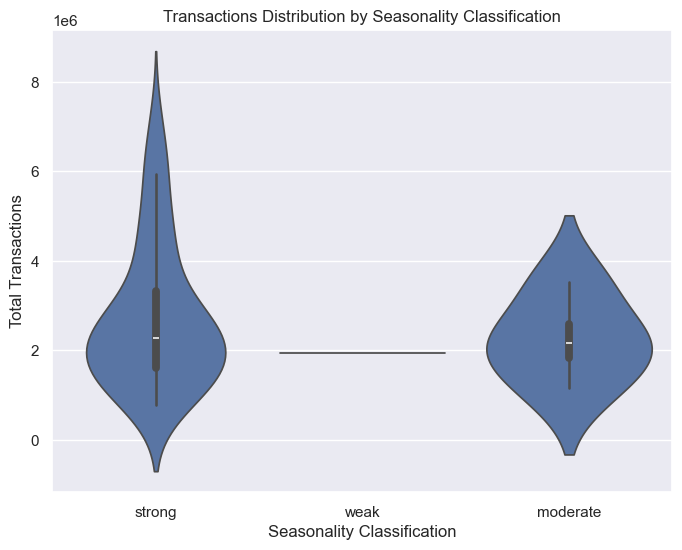

In [37]:
plt.rcParams['figure.figsize'] = (8, 6)

ax = sns.violinplot(
    data=df_time_series_analysis_results,
    x='seasonality_classification',
    y='total_transactions'
)

ax.set_title('Transactions Distribution by Seasonality Classification')

ax.set_xlabel('Seasonality Classification')
ax.set_ylabel('Total Transactions')

plt.show()

We can see that seasonal series have a greater median and a greater total transactions amount.

### 3. 2. 2. Trend

In [38]:
trend_series = df_time_series_analysis_results[df_time_series_analysis_results['trend_classification'] != 'weak']
non_trend_series = df_time_series_analysis_results[df_time_series_analysis_results['trend_classification'] == 'weak']

display(
     df_time_series_analysis_results
    .groupby('trend_classification')['total_transactions'].sum()
    .reset_index()
    .sort_values(by='total_transactions', ascending=False)
)

print(f"{len(trend_series) / len(df_time_series_analysis_results):.2%} series have a moderate/strong trend component")
print(f"{len(non_trend_series) / len(df_time_series_analysis_results):.2%} series do not have a moderate/strong trend component")

print(f"\n\nSeries with trend's transactions median: {trend_series['total_transactions'].median():.2f}")
print(f"Series with no trend's transactions median: {non_trend_series['total_transactions'].median():.2f}")

,trend_classification,total_transactions
1,strong,75397285
0,moderate,36476011
2,weak,27451971


80.77% series have a moderate/strong trend component
19.23% series do not have a moderate/strong trend component


Series with trend's transactions median: 2174316.50
Series with no trend's transactions median: 2749641.50


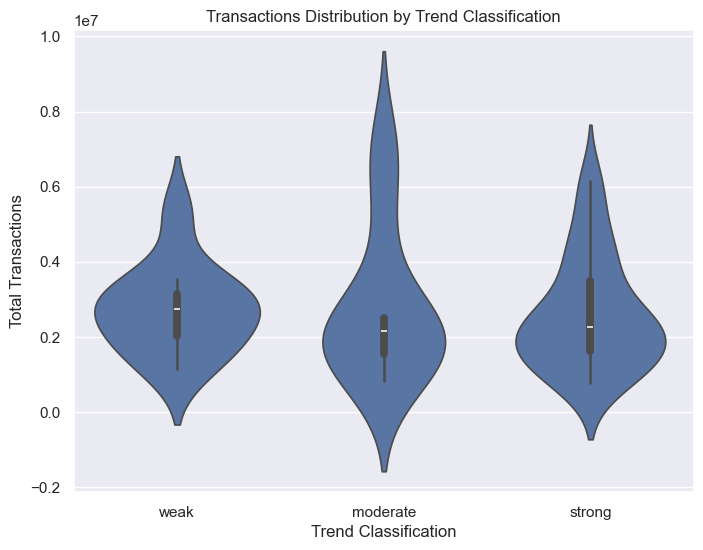

In [39]:
plt.rcParams['figure.figsize'] = (8, 6)

ax = sns.violinplot(
    data=df_time_series_analysis_results,
    x='trend_classification',
    y='total_transactions'
)

ax.set_title('Transactions Distribution by Trend Classification')

ax.set_xlabel('Trend Classification')
ax.set_ylabel('Total Transactions')

plt.show()

We can also see that the series with a trend have a greater total transactions amount.

### 3. 2. 3. Noise

In [40]:
noisy_series = df_time_series_analysis_results[df_time_series_analysis_results['noise_classification'] == 'strong']
non_noisy_series = df_time_series_analysis_results[df_time_series_analysis_results['noise_classification'].isin(['moderate', 'weak'])]

display(
     df_time_series_analysis_results
    .groupby('noise_classification')['total_transactions'].sum()
    .reset_index()
    .sort_values(by='total_transactions', ascending=False)
)

print(f"{len(noisy_series)/len(df_time_series_analysis_results):.2%} series are noisy")
print(f"{len(non_noisy_series)/len(df_time_series_analysis_results):.2%} series are not noisy")

print(f"\n\nNoisy series' transactions median: {noisy_series['total_transactions'].median():.2f}")
print(f"Non-noisy series' transactions median: {non_noisy_series['total_transactions'].median():.2f}")

,noise_classification,total_transactions
2,weak,123589305
1,strong,8902786
0,moderate,6833176


7.69% series are noisy
92.31% series are not noisy


Noisy series' transactions median: 2104248.00
Non-noisy series' transactions median: 2277930.50


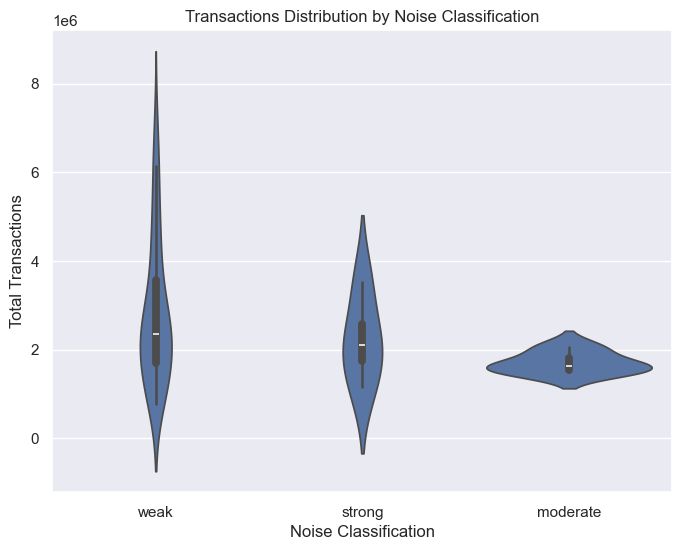

In [41]:
plt.rcParams['figure.figsize'] = (8, 6)

ax = sns.violinplot(
    data=df_time_series_analysis_results,
    x='noise_classification',
    y='total_transactions'
)

ax.set_title('Transactions Distribution by Noise Classification')

ax.set_xlabel('Noise Classification')
ax.set_ylabel('Total Transactions')

plt.show()

We can see that non-noisy series got a bigger total transactions amount.

### 3. 2. 4. Stationarity

In [42]:
# Stationary series
stationary_series = df_time_series_analysis_results[df_time_series_analysis_results['stationary']]
non_stationary_series = df_time_series_analysis_results[df_time_series_analysis_results['stationary'] == False]

display(
     df_time_series_analysis_results
    .groupby('stationary')['total_transactions'].sum()
    .reset_index()
    .sort_values(by='total_transactions', ascending=False)
)

print(f"{len(stationary_series)/len(df_time_series_analysis_results):.2%} series are stationary")
print(f"{len(non_stationary_series)/len(df_time_series_analysis_results):.2%} series are not stationary")

print(f"\n\nStationary series' transactions median: {stationary_series['total_transactions'].median():.2f}")
print(f"Non-stationary series' transactions median: {non_stationary_series['total_transactions'].median():.2f}")

,stationary,total_transactions
0,False,108367289
1,True,30957978


28.85% series are stationary
71.15% series are not stationary


Stationary series' transactions median: 1720127.00
Non-stationary series' transactions median: 2459364.00


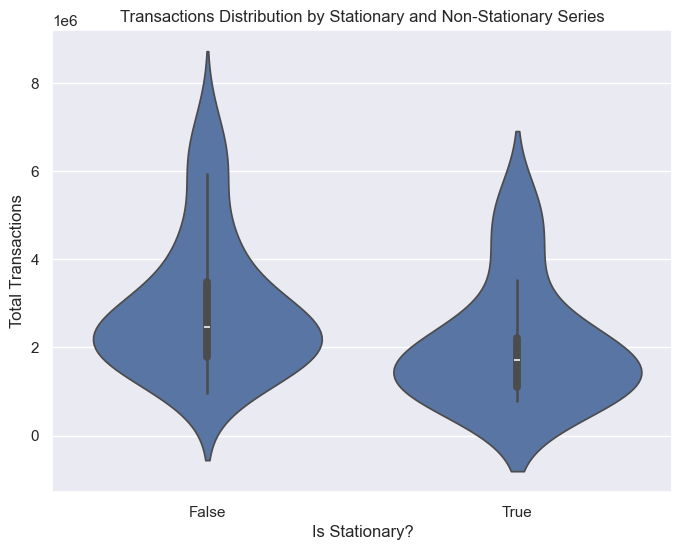

In [43]:
plt.rcParams['figure.figsize'] = (8, 6)

ax = sns.violinplot(
    data=df_time_series_analysis_results,
    x='stationary',
    y='total_transactions'
)

ax.set_title('Transactions Distribution by Stationary and Non-Stationary Series')

ax.set_xlabel('Is Stationary?')
ax.set_ylabel('Total Transactions')

plt.show()

Non-stationary series' sales median is greater with a much greater total sales amount.

### 3. 2. 5. Demand type

In [44]:
display(
     df_time_series_analysis_results
    .groupby('demand_type')['total_transactions'].sum()
    .reset_index()
    .sort_values(by='total_transactions', ascending=False)
)

,demand_type,total_transactions
0,smooth,139325267


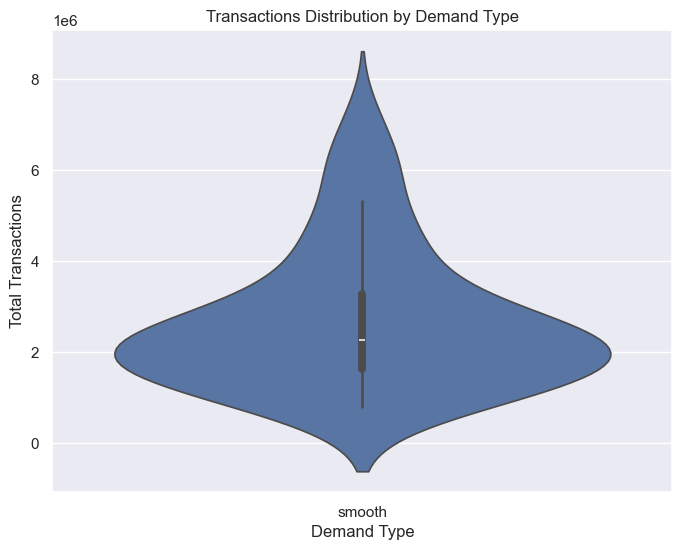

In [45]:
plt.rcParams['figure.figsize'] = (8, 6)

ax = sns.violinplot(
    data=df_time_series_analysis_results,
    x='demand_type',
    y='total_transactions'
)

ax.set_title('Transactions Distribution by Demand Type')

ax.set_xlabel('Demand Type')
ax.set_ylabel('Total Transactions')

plt.show()

There are only smooth series.

# 5. Summary

The majority of the stores do have a significant annual seasonality and trend patterns, that is even more clear in the store level than in the store/family level, including the ones that are relevant for the business. Having that in mind, using features like month, year or the mean seasonality/trend for value for a single month can be really useful to predict the demand for a store/family.

As it seems easier to predict the demand for a single store, because the stores' pattern are better outlined, we can even think in a multi-level model, in which it's first predicted the demand for a store and later for each one of their families.